**Phase 1**
- Image loading
- Grayscaling
- Stereo disparity

**Phase 2**
- Depth visualization

**Phase 3**
- Biscuit segmentation

**Phase 4**
- Pseudo-3D recosntruction

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# LOAD IMAGE
# -----------------------------------

image = cv2.imread("/content/45deg view.jpeg")

if image is None:
    print("ERROR: Image not found.")
    exit()



In [2]:
# Convert to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [4]:
# BLUR
blur = cv2.GaussianBlur(gray, (5, 5), 0)

In [8]:
# GRADIENTS
# X gradient - how reapidly pixel density increase
grad_x = cv2.Sobel(
    blur,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

# Y gradient
grad_y = cv2.Sobel(
    blur,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# Gradient magnitude
gradient_magnitude = cv2.magnitude(
    grad_x,
    grad_y
)


In [6]:
# Normalize
depth_map = cv2.normalize(
    gradient_magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

depth_map = np.uint8(depth_map)


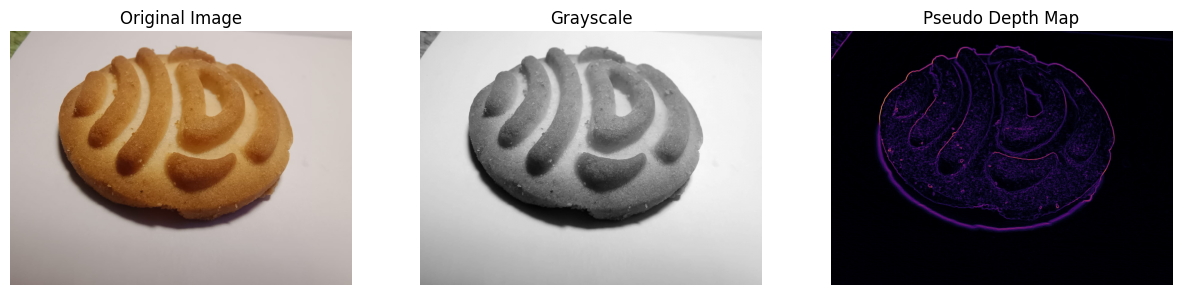

In [7]:
# DISPLAY

plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")

# Grayscale
plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Depth approximation
plt.subplot(1,3,3)
plt.imshow(depth_map, cmap='inferno')
plt.title("Pseudo Depth Map")
plt.axis("off")

plt.show()

Bright areas in the pseudo depth map mean- image intensity changes strongly here.

Thickenss analysis

In [9]:
# LOAD IMAGE - side view

image2 = cv2.imread("/content/side view.jpeg")

if image is None:
    print("ERROR: Image not found.")
    exit()

In [10]:
# Convert BGR to RGB
rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# BLUR
blur = cv2.GaussianBlur(gray, (5, 5), 0)


In [11]:
 #THRESHOLD SEGMENTATION

_, thresh = cv2.threshold(
    blur,
    140,
    255,
    cv2.THRESH_BINARY_INV
)


In [12]:
# FIND CONTOURS

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Largest contour = biscuit
largest_contour = max(contours, key=cv2.contourArea)

# Creating mask
mask = np.zeros_like(gray)

cv2.drawContours(
    mask,
    [largest_contour],
    -1,
    255,
    thickness=cv2.FILLED
)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)

In [13]:
# EXTRACT THICKNESS PROFILE

height, width = mask.shape

top_points = []
bottom_points = []
thickness_values = []

for x in range(width):

    ys = np.where(mask[:, x] == 255)[0]

    if len(ys) > 0:

        top_y = ys.min()
        bottom_y = ys.max()

        thickness = bottom_y - top_y

        top_points.append(top_y)
        bottom_points.append(bottom_y)
        thickness_values.append(thickness)

    else:
        top_points.append(np.nan)
        bottom_points.append(np.nan)
        thickness_values.append(np.nan)

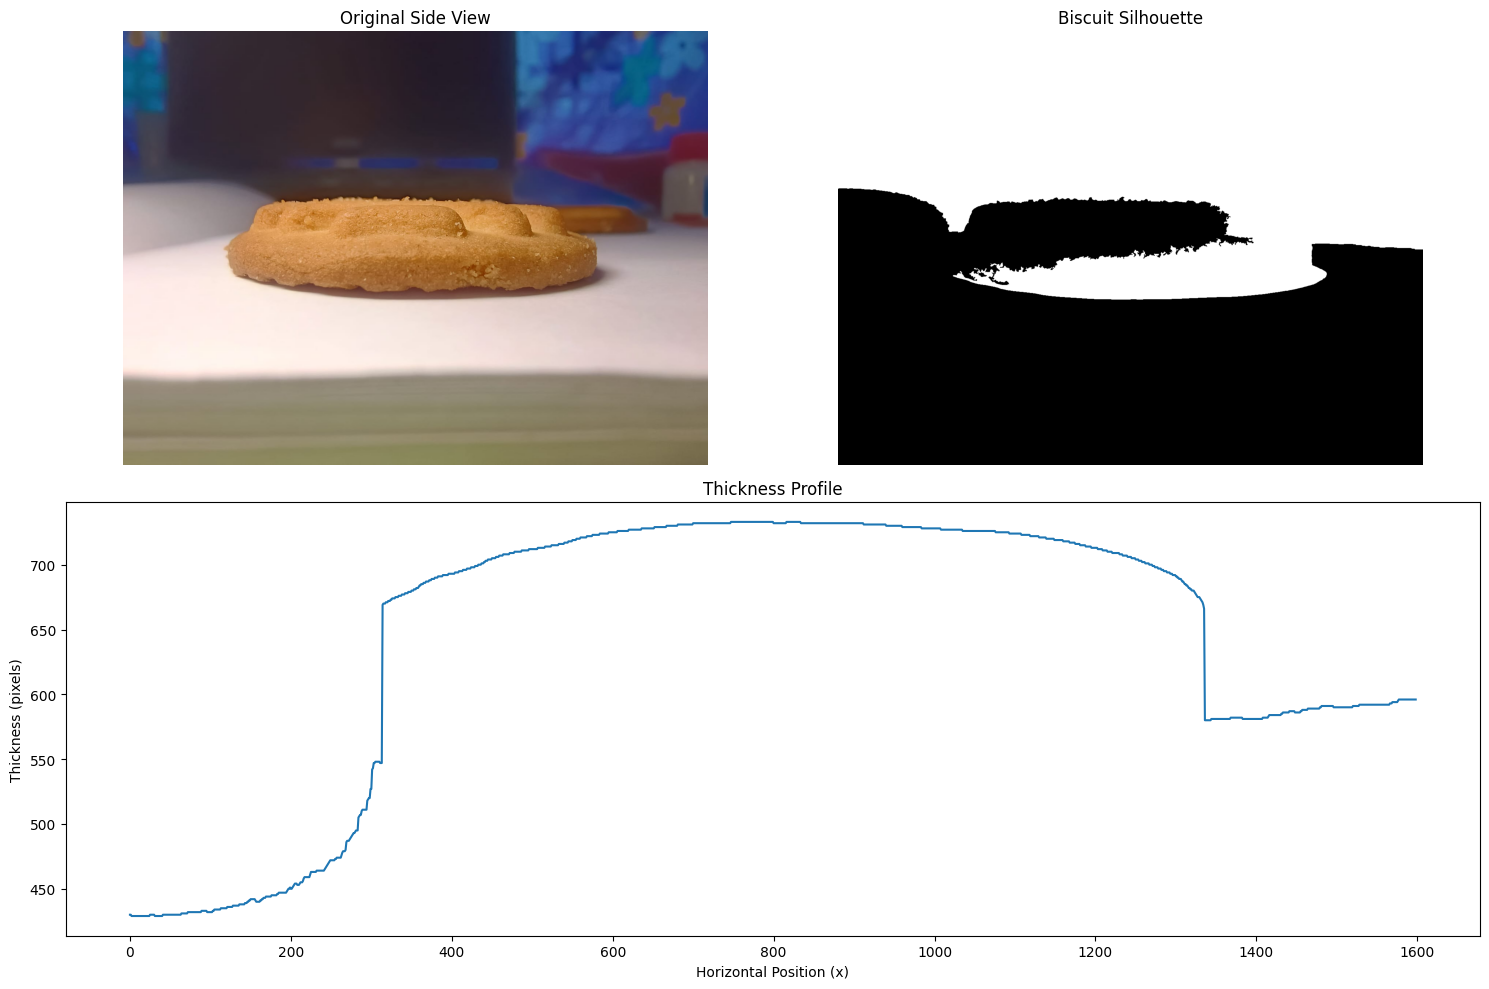

In [14]:
# DISPLAY RESULTS

plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2,2,1)
plt.imshow(rgb)
plt.title("Original Side View")
plt.axis("off")

# Threshold mask
plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Biscuit Silhouette")
plt.axis("off")

# Thickness curve
plt.subplot(2,1,2)
plt.plot(thickness_values)

plt.title("Thickness Profile")
plt.xlabel("Horizontal Position (x)")
plt.ylabel("Thickness (pixels)")

plt.tight_layout()
plt.show()

In [15]:
# PRINT RESULTS

valid_thickness = [
    t for t in thickness_values
    if not np.isnan(t)
]

max_thickness = np.max(valid_thickness)
min_thickness = np.min(valid_thickness)
avg_thickness = np.mean(valid_thickness)

print("\n===== THICKNESS ANALYSIS =====")

print(f"Maximum Thickness: {max_thickness:.2f} pixels")
print(f"Minimum Thickness: {min_thickness:.2f} pixels")
print(f"Average Thickness: {avg_thickness:.2f} pixels")


===== THICKNESS ANALYSIS =====
Maximum Thickness: 733.00 pixels
Minimum Thickness: 429.00 pixels
Average Thickness: 643.78 pixels


Surface Profile

In [17]:
# SMOOTH PROFILE

valid = np.nan_to_num(thickness_values)

kernel_size = 15

kernel = np.ones(kernel_size) / kernel_size

smooth_profile = np.convolve(
    valid,
    kernel,
    mode='same'
)

In [18]:
# PEAK DETECTION|

peaks = []

for i in range(1, len(smooth_profile)-1):

    if (
        smooth_profile[i] > smooth_profile[i-1]
        and
        smooth_profile[i] > smooth_profile[i+1]
        and
        smooth_profile[i] > np.mean(smooth_profile)
    ):

        peaks.append(i)

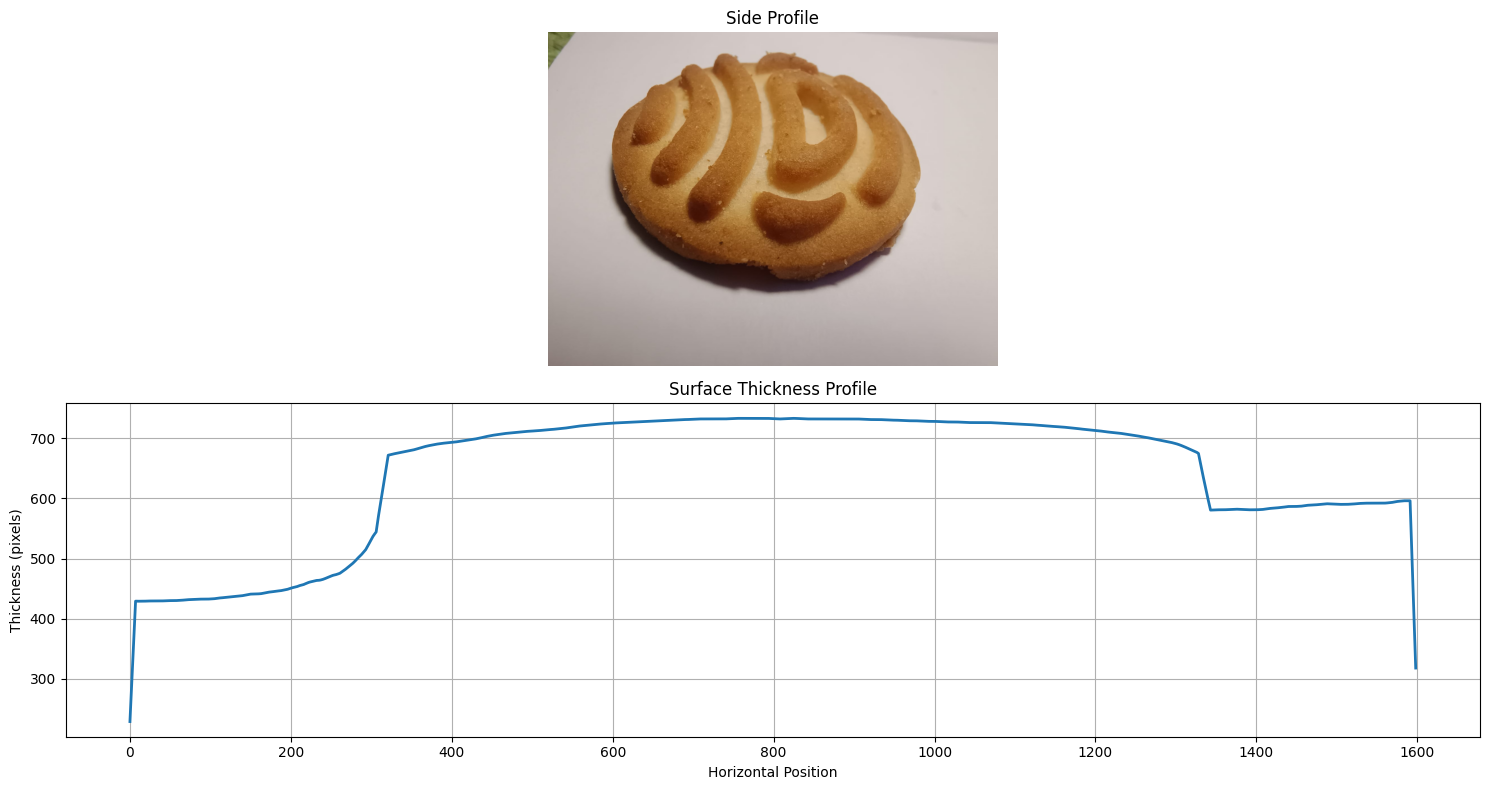

In [20]:
plt.figure(figsize=(15,8))

# Original image
plt.subplot(2,1,1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.title("Side Profile")

plt.axis("off")

# Surface profile
plt.subplot(2,1,2)

plt.plot(smooth_profile, linewidth=2)

# Mark peaks
for p in peaks:
    plt.scatter(
        p,
        smooth_profile[p],
        s=80
    )

plt.title("Surface Thickness Profile")

plt.xlabel("Horizontal Position")

plt.ylabel("Thickness (pixels)")

plt.grid(True)

plt.tight_layout()

plt.show()


In [22]:
# PRINT RESULTS

print("SURFACE ANALYSIS :")

print(f"Detected Ridge Peaks: {len(peaks)}")

print(f"Maximum Height: {np.max(smooth_profile):.2f} pixels")

print(f"Average Height: {np.mean(smooth_profile):.2f} pixels")

SURFACE ANALYSIS :
Detected Ridge Peaks: 0
Maximum Height: 733.00 pixels
Average Height: 642.58 pixels
